# 10 — Interpretabilidad, subgrupos y calibración

Auditoría descriptiva del CatBoost principal congelado. Reproduce el ajuste 2020–2024 y evalúa 2025 sin modificar parámetros. Las asociaciones e importancias no son explicaciones causales ni criterios automatizados de atención.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'salidas_modelado' / 'bases_finales_riesgo'
OUTPUT_DIR = BASE_DIR / 'salidas_modelado' / 'auditoria_modelo_principal'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = BASE_DIR / 'modelos'

TARGET = 'NIVEL_DE_RIESGO_VICTIMA'
LABELS = ['1', '2', '3']
RANDOM_SEED = 20260827

ruta_modelo_principal = MODELS_DIR / 'catboost_inicial_parsimonioso_2020_2024.cbm'
ruta_configuracion_principal = MODELS_DIR / 'catboost_inicial_parsimonioso_2020_2024.config.json'

if ruta_configuracion_principal.exists():
    configuracion_principal = json.loads(ruta_configuracion_principal.read_text(encoding='utf-8'))
    FEATURES = configuracion_principal.get('features', [
        'VINCULO_AGRESOR_VICTIMA', 'PRIMERA_VEZ_AGREDE', 'ESTADO_AGRESOR_U_A',
        'EDAD_VICTIMA', 'NIVEL_EDUCATIVO_VICTIMA', 'AREA_RESIDENCIA_DOMICILIO',
        'REDES_FAM_SOC', 'SEXO_AGRESOR', 'SEXO_VICTIMA'
    ])
else:
    FEATURES = [
        'VINCULO_AGRESOR_VICTIMA', 'PRIMERA_VEZ_AGREDE', 'ESTADO_AGRESOR_U_A',
        'EDAD_VICTIMA', 'NIVEL_EDUCATIVO_VICTIMA', 'AREA_RESIDENCIA_DOMICILIO',
        'REDES_FAM_SOC', 'SEXO_AGRESOR', 'SEXO_VICTIMA'
    ]

EJECUTAR_AUDITORIA = True


In [3]:
def cargar(corte):
    sufijos={'train':'train_2020_2023','validacion':'validacion_2024','prueba':'prueba_2025'}
    x=pd.read_parquet(DATA_DIR/f'riesgo_inicial_{sufijos[corte]}.parquet'); x['EDAD_VICTIMA']=pd.to_numeric(x['EDAD_VICTIMA'],errors='raise'); return x

def preparar(tabla):
    x=tabla[FEATURES].copy(); cat=[c for c in FEATURES if c!='EDAD_VICTIMA']
    for c in cat: x[c]=x[c].astype(str)
    return x,cat

def metricas_grupo(tabla, pred, columna):
    filas=[]
    for grupo, idx in tabla.groupby(columna, dropna=False).groups.items():
        y=tabla.loc[idx,TARGET].astype(str); p=pd.Series(pred,index=tabla.index).loc[idx]
        if len(y)>=100 and y.nunique()==3:
            _,recall,_,_=precision_recall_fscore_support(y,p,labels=LABELS,zero_division=0)
            filas.append({'subgrupo':columna,'nivel':str(grupo),'n':len(y),'macro_f1':f1_score(y,p,labels=LABELS,average='macro',zero_division=0),'balanced_accuracy':balanced_accuracy_score(y,p),'recall_severo':recall[2]})
    return filas


,feature,importancia_catboost
3,EDAD_VICTIMA,21.158157
0,VINCULO_AGRESOR_VICTIMA,19.509814
1,PRIMERA_VEZ_AGREDE,15.295575
2,ESTADO_AGRESOR_U_A,14.264552
6,REDES_FAM_SOC,7.222627
4,NIVEL_EDUCATIVO_VICTIMA,6.946644
7,SEXO_AGRESOR,6.343510
8,SEXO_VICTIMA,5.327735
5,AREA_RESIDENCIA_DOMICILIO,3.931386


C:\Users\jcollazos\AppData\Local\Temp\ipykernel_31268\3218232175.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, idx in tabla.groupby(columna, dropna=False).groups.items():


,subgrupo,nivel,n,macro_f1,balanced_accuracy,recall_severo
0,grupo_edad,0-17,64345,0.412453,0.472168,0.611733
1,grupo_edad,18-29,35040,0.410889,0.433871,0.560757
2,grupo_edad,30-44,42335,0.439707,0.447709,0.467526
3,grupo_edad,45-59,16925,0.443049,0.475478,0.436721
4,grupo_edad,60+,10891,0.434175,0.465464,0.353931
5,SEXO_VICTIMA,0,141808,0.429472,0.453648,0.572243
6,SEXO_VICTIMA,1,27728,0.388765,0.444359,0.293111
7,AREA_RESIDENCIA_DOMICILIO,1,140505,0.434718,0.460984,0.494353
8,AREA_RESIDENCIA_DOMICILIO,2,29031,0.374316,0.464157,0.712947


,clase,brier_multiclase_ovr
0,Leve,0.158269
1,Moderado,0.277136
2,Severo,0.198956


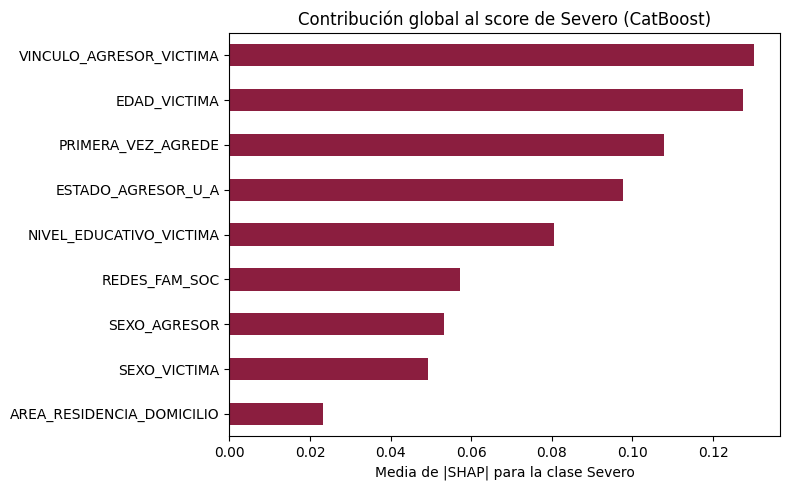

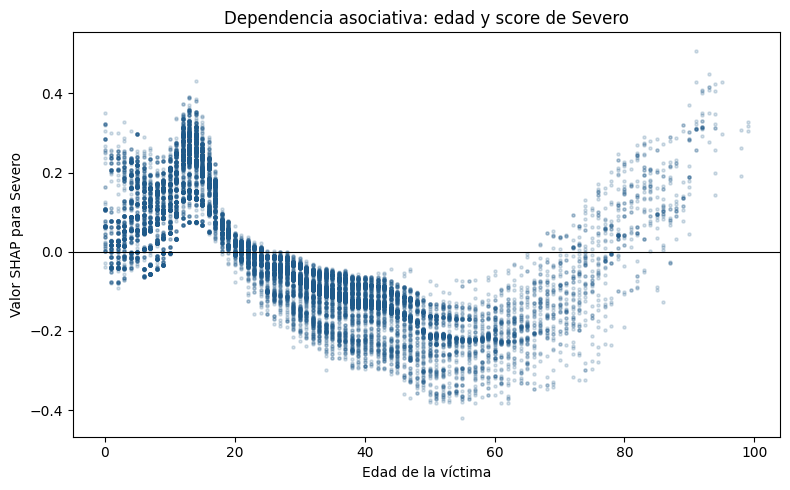

In [4]:
if EJECUTAR_AUDITORIA:
    test = cargar('prueba')
    X_test, cat = preparar(test)

    modelo = CatBoostClassifier()
    if ruta_modelo_principal.exists():
        modelo.load_model(str(ruta_modelo_principal))
        print(f'Modelo congelado cargado exitosamente desde: {ruta_modelo_principal}')
    else:
        train = pd.concat([cargar('train'), cargar('validacion')], ignore_index=True)
        X_train, cat_train = preparar(train)
        modelo = CatBoostClassifier(
            loss_function='MultiClass', iterations=300, learning_rate=0.05, depth=6,
            auto_class_weights='Balanced', random_seed=RANDOM_SEED, thread_count=-1,
            verbose=False, allow_writing_files=False
        )
        modelo.fit(X_train, train[TARGET].astype(int), cat_features=cat_train)
        print('Aviso: Modelo reentrenado localmente porque no se encontró el artefacto congelado del notebook 09.')

    pred = np.asarray(modelo.predict(X_test)).reshape(-1).astype(str)
    prob = modelo.predict_proba(X_test)
    importancia = pd.DataFrame({'feature': FEATURES, 'importancia_catboost': modelo.get_feature_importance()}).sort_values('importancia_catboost', ascending=False)
    importancia.to_csv(OUTPUT_DIR / 'importancia_variables.csv', index=False, encoding='utf-8-sig')
    display(importancia)

    grupos = test.copy()
    grupos['grupo_edad'] = pd.cut(grupos['EDAD_VICTIMA'], bins=[-1, 17, 29, 44, 59, 200], labels=['0-17', '18-29', '30-44', '45-59', '60+'])
    auditoria = []
    for columna in ['grupo_edad', 'SEXO_VICTIMA', 'AREA_RESIDENCIA_DOMICILIO']:
        auditoria += metricas_grupo(grupos, pred, columna)
    auditoria = pd.DataFrame(auditoria)
    auditoria.to_csv(OUTPUT_DIR / 'metricas_subgrupos_2025.csv', index=False, encoding='utf-8-sig')
    display(auditoria)

    y_bin = label_binarize(test[TARGET].astype(str), classes=LABELS)
    brier = ((y_bin - prob) ** 2).mean(axis=0)
    calibracion = pd.DataFrame({'clase': ['Leve', 'Moderado', 'Severo'], 'brier_multiclase_ovr': brier})
    calibracion.to_csv(OUTPUT_DIR / 'calibracion_brier_2025.csv', index=False, encoding='utf-8-sig')
    display(calibracion)

    import matplotlib.pyplot as plt
    from catboost import Pool
    muestra_shap = X_test.sample(n=min(20_000, len(X_test)), random_state=RANDOM_SEED)
    valores_shap = np.asarray(modelo.get_feature_importance(Pool(muestra_shap, cat_features=cat), type='ShapValues'))
    if valores_shap.ndim == 3 and valores_shap.shape[1] == 3:
        shap_severo = valores_shap[:, 2, :-1]
    elif valores_shap.ndim == 3 and valores_shap.shape[2] == 3:
        shap_severo = valores_shap[:, :-1, 2]
    else:
        raise ValueError(f'Forma SHAP no esperada: {valores_shap.shape}')
    resumen_shap = pd.DataFrame({'feature': FEATURES, 'media_abs_shap_severo': np.abs(shap_severo).mean(axis=0)}).sort_values('media_abs_shap_severo', ascending=False)
    resumen_shap.to_csv(OUTPUT_DIR / 'shap_global_severo.csv', index=False, encoding='utf-8-sig')
    ax = resumen_shap.sort_values('media_abs_shap_severo').plot.barh(x='feature', y='media_abs_shap_severo', legend=False, figsize=(8, 5), color='#8b1e3f')
    ax.set_xlabel('Media de |SHAP| para la clase Severo'); ax.set_ylabel(''); ax.set_title('Contribución global al score de Severo (CatBoost)')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'shap_global_severo.png', dpi=180); plt.show()
    edad_idx = FEATURES.index('EDAD_VICTIMA')
    plt.figure(figsize=(8, 5)); plt.scatter(muestra_shap['EDAD_VICTIMA'], shap_severo[:, edad_idx], s=5, alpha=.18, color='#1f5a8a')
    plt.axhline(0, color='black', linewidth=.8); plt.xlabel('Edad de la víctima'); plt.ylabel('Valor SHAP para Severo'); plt.title('Dependencia asociativa: edad y score de Severo')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'shap_dependencia_edad_severo.png', dpi=180); plt.show()
else:
    print('Auditoría no ejecutada. Cambie EJECUTAR_AUDITORIA a True.')


## Cómo interpretar

Las importancias y SHAP indican cuánto utiliza el modelo cada variable, no una relación causal ni una recomendación de intervención. SHAP explica cómo las variables desplazan una predicción dentro del modelo y de estos datos; no separa confusión, causa y consecuencia. Las métricas por subgrupo se interpretan junto con su tamaño muestral; diferencias requieren investigación adicional y no justifican decisiones discriminatorias. El Brier one-vs-rest mide error cuadrático de probabilidad: valores menores son preferibles, pero no se recalibra con 2025.